In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore") 

from difflib import SequenceMatcher
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
url = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")

In [3]:
url.shape
total_row = url.shape[0]

In [4]:
url.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [5]:
url.describe().T

,count,mean,std,min,25%,50%,75%,max
URLLength,235712.0,34.572665,41.318567,13.000000,23.000000,27.000000,34.000000,6.097000e+03
DomainLength,235711.0,21.470474,9.151150,4.000000,16.000000,20.000000,24.000000,1.100000e+02
IsDomainIP,235712.0,0.002707,0.051956,0.000000,0.000000,0.000000,0.000000,1.000000e+00
URLSimilarityIndex,235705.0,78.431034,28.975736,0.155574,57.027778,100.000000,100.000000,1.000000e+02
CharContinuationRate,235690.0,0.845508,0.216627,0.000000,0.680000,1.000000,1.000000,1.000000e+00
TLDLegitimateProb,235707.0,0.260433,0.251628,0.000000,0.005977,0.079963,0.522907,5.229071e-01
URLCharProb,235732.0,0.055747,0.010587,0.001083,0.050747,0.057970,0.062875,9.082366e-02
TLDLength,235712.0,2.764471,0.599764,2.000000,2.000000,3.000000,3.000000,1.300000e+01
NoOfSubDomain,235725.0,1.164756,0.600988,0.000000,1.000000,1.000000,1.000000,1.000000e+01
HasObfuscation,235711.0,0.002058,0.045314,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [6]:
url.rename(
    columns={
        "NoOfDegitsInURL": "NoOfDigitsInURL",
        "DegitRatioInURL": "DigitRatioInURL",
        "SpacialCharRatioInURL": "SpecialCharRatioInURL"
    },
    inplace=True  
)

In [7]:
url.drop(columns=['FILENAME'], inplace=True)

In [9]:
print(f"Total null values : {url.isnull().sum().sum()}")

Total null values : 4124


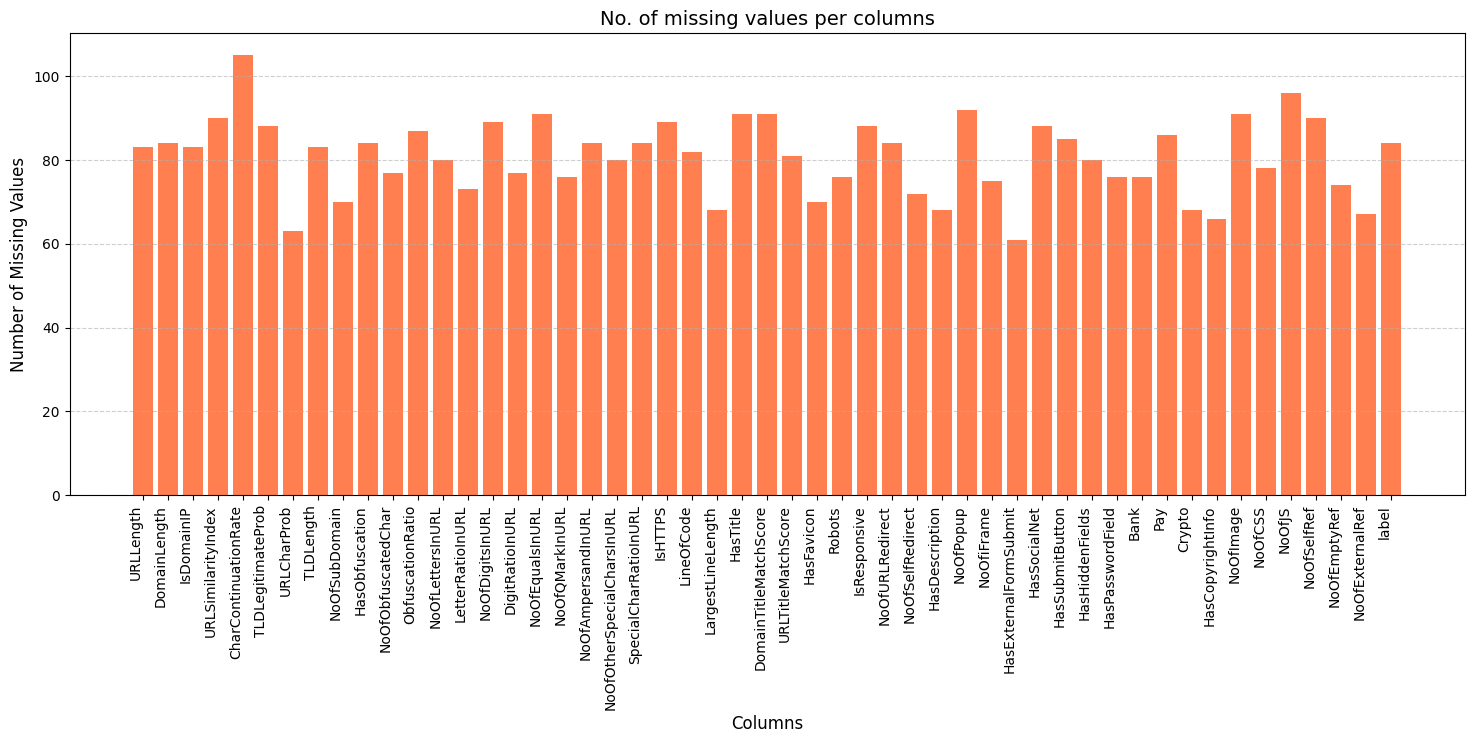

In [10]:
null_dict = {col: url[col].isna().sum() for col in url.columns if url[col].isnull().sum() > 0}

plt.figure(figsize=(18, 6))
plt.bar(null_dict.keys(), null_dict.values(), color='coral')
plt.title('No. of missing values per columns', fontsize=14)
plt.xlabel('Columns', fontsize=12)
plt.ylabel('Number of Missing Values', fontsize=12)
plt.xticks(rotation=90, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [11]:
url = url.dropna(subset=[
    'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio','HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 
    'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
    'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS',
    'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef', 'label'
])

In [12]:
url['URLLength'] = url['URLLength'].fillna(url['URL'].apply(lambda x: len(str(x))))
url['DomainLength'] = url['DomainLength'].fillna(url['Domain'].apply(lambda x: len(str(x))))

tld_prob = (url.groupby('TLD')['TLDLegitimateProb'].mean().to_dict())
url['TLDLegitimateProb'] = url.apply(
    lambda row: tld_prob[row['TLD']] if pd.isnull(row['TLDLegitimateProb']) and row['TLD'] in tld_prob else row['TLDLegitimateProb'], 
    axis=1
)
url = url.dropna(subset=['TLDLegitimateProb'])

correlation = url['URLCharProb'].corr(url['label']) 
if abs(correlation) > 0.7:
    url.dropna(subset=['URLCharProb'], inplace=True)
else:
    url['URLCharProb'].fillna(url['URLCharProb'].mean(), inplace=True)

url['TLDLength'] = url['TLDLength'].fillna(url['TLD'].apply(lambda x: len(str(x))))

tld_subdomain = url.groupby('TLD')['NoOfSubDomain'].mean().to_dict()
url['NoOfSubDomain'] = url.apply(
    lambda row: tld_subdomain[row['TLD']] if pd.isnull(row['NoOfSubDomain']) and row['TLD'] in tld_subdomain else row['NoOfSubDomain'], 
    axis=1
)
url = url.dropna(subset=['NoOfSubDomain'])

url['NoOfLettersInURL'] = url['NoOfLettersInURL'].fillna(
    url['URL'].apply(lambda x: sum(c.isalpha() for c in str(x)))
)

url['NoOfDigitsInURL'] = url['NoOfDigitsInURL'].fillna(
    url['URL'].apply(lambda x: sum(c.isdigit() for c in str(x)))
)

url['NoOfEqualsInURL'] = url['NoOfEqualsInURL'].fillna(url['URL'].apply(lambda x: str(x).count('=')))
url['NoOfQMarkInURL'] = url['NoOfQMarkInURL'].fillna(url['URL'].apply(lambda x: str(x).count('?')))
url['NoOfAmpersandInURL'] = url['NoOfAmpersandInURL'].fillna(url['URL'].apply(lambda x: str(x).count('&')))

special_chars = ['/', '.', '-', '_', '@', '#', '%', '?', '&', '=']
url['NoOfOtherSpecialCharsInURL'] = url['NoOfOtherSpecialCharsInURL'].fillna(
    url['URL'].apply(lambda x: sum(str(x).count(char) for char in special_chars))
)

url['IsHTTPS'] = url['IsHTTPS'].fillna(url['URL'].apply(lambda x: 1 if str(x).startswith('https') else 0))

correlation = url['LineOfCode'].corr(url['label']) 
if abs(correlation) > 0.7:
    url.dropna(subset=['LineOfCode'], inplace=True)
    url.dropna(subset=['LargestLineLength'], inplace=True)
else:
    url['LineOfCode'].fillna(url['LineOfCode'].mean(), inplace=True)
    url['LargestLineLength'].fillna(url['LargestLineLength'].mean(), inplace=True)

url['LetterRatioInURL'] = url['LetterRatioInURL'].fillna(url['NoOfLettersInURL'] / url['URLLength'])
url['DigitRatioInURL'] = url['DigitRatioInURL'].fillna(url['NoOfDigitsInURL'] / url['URLLength'])
url['SpecialCharRatioInURL'] = url['SpecialCharRatioInURL'].fillna(url['NoOfOtherSpecialCharsInURL'] / url['URLLength'])

url['HasTitle'] = url['HasTitle'].fillna(url['Title'].apply(lambda x: 1 if pd.notnull(x) and str(x).strip() != '' else 0))

def similarity_score(str1, str2):
    if pd.isnull(str1) or pd.isnull(str2):
        return np.nan  # Keep NaN for missing values
    return SequenceMatcher(None, str(str1), str(str2)).ratio()
url['DomainTitleMatchScore'] = url.apply(lambda row: similarity_score(row['Domain'], row['Title']), axis=1)
url['URLTitleMatchScore'] = url.apply(lambda row: similarity_score(row['URL'], row['Title']), axis=1)

In [13]:
rows_loss = (1 - url.shape[0] / total_row) * 100
print(f"Percent Rows Lost Due to NaN: {rows_loss:.2f} %")

Percent Rows Lost Due to NaN: 1.02 %


In [17]:
dist_feats = [col for col in url.select_dtypes(exclude='object').columns if url[col].nunique() > 2]

skewness = []
for col in dist_feats:
    skewness.append(url[col].skew())

In [18]:
def plot_boxplot(df, columns):
    num_cols = len(columns)
    rows = (num_cols // 3) + (num_cols % 3 > 0)  # Calculate rows needed (3 per row)
    
    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten in case of a single row
    
    for i, col in enumerate(columns):
        axes[i].boxplot(df[col], vert=True, patch_artist=True)
        axes[i].set_title(f'Boxplot of {col}')
        axes[i].set_xlabel(col)

    # Hide unused subplots if columns are not a multiple of 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

def plot_distributions(df, columns):
    rows = int(np.ceil(len(columns) / 3))  # Calculate number of rows needed
    fig, axes = plt.subplots(rows, 3, figsize=(15, rows * 3))
    
    axes = axes.flatten()  # Flatten in case of a single row
    
    for i, col in enumerate(columns):
        sns.histplot(df[col], bins=50, kde=True, ax=axes[i], color='blue')
        axes[i].set_title(f'{col}')
    
    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

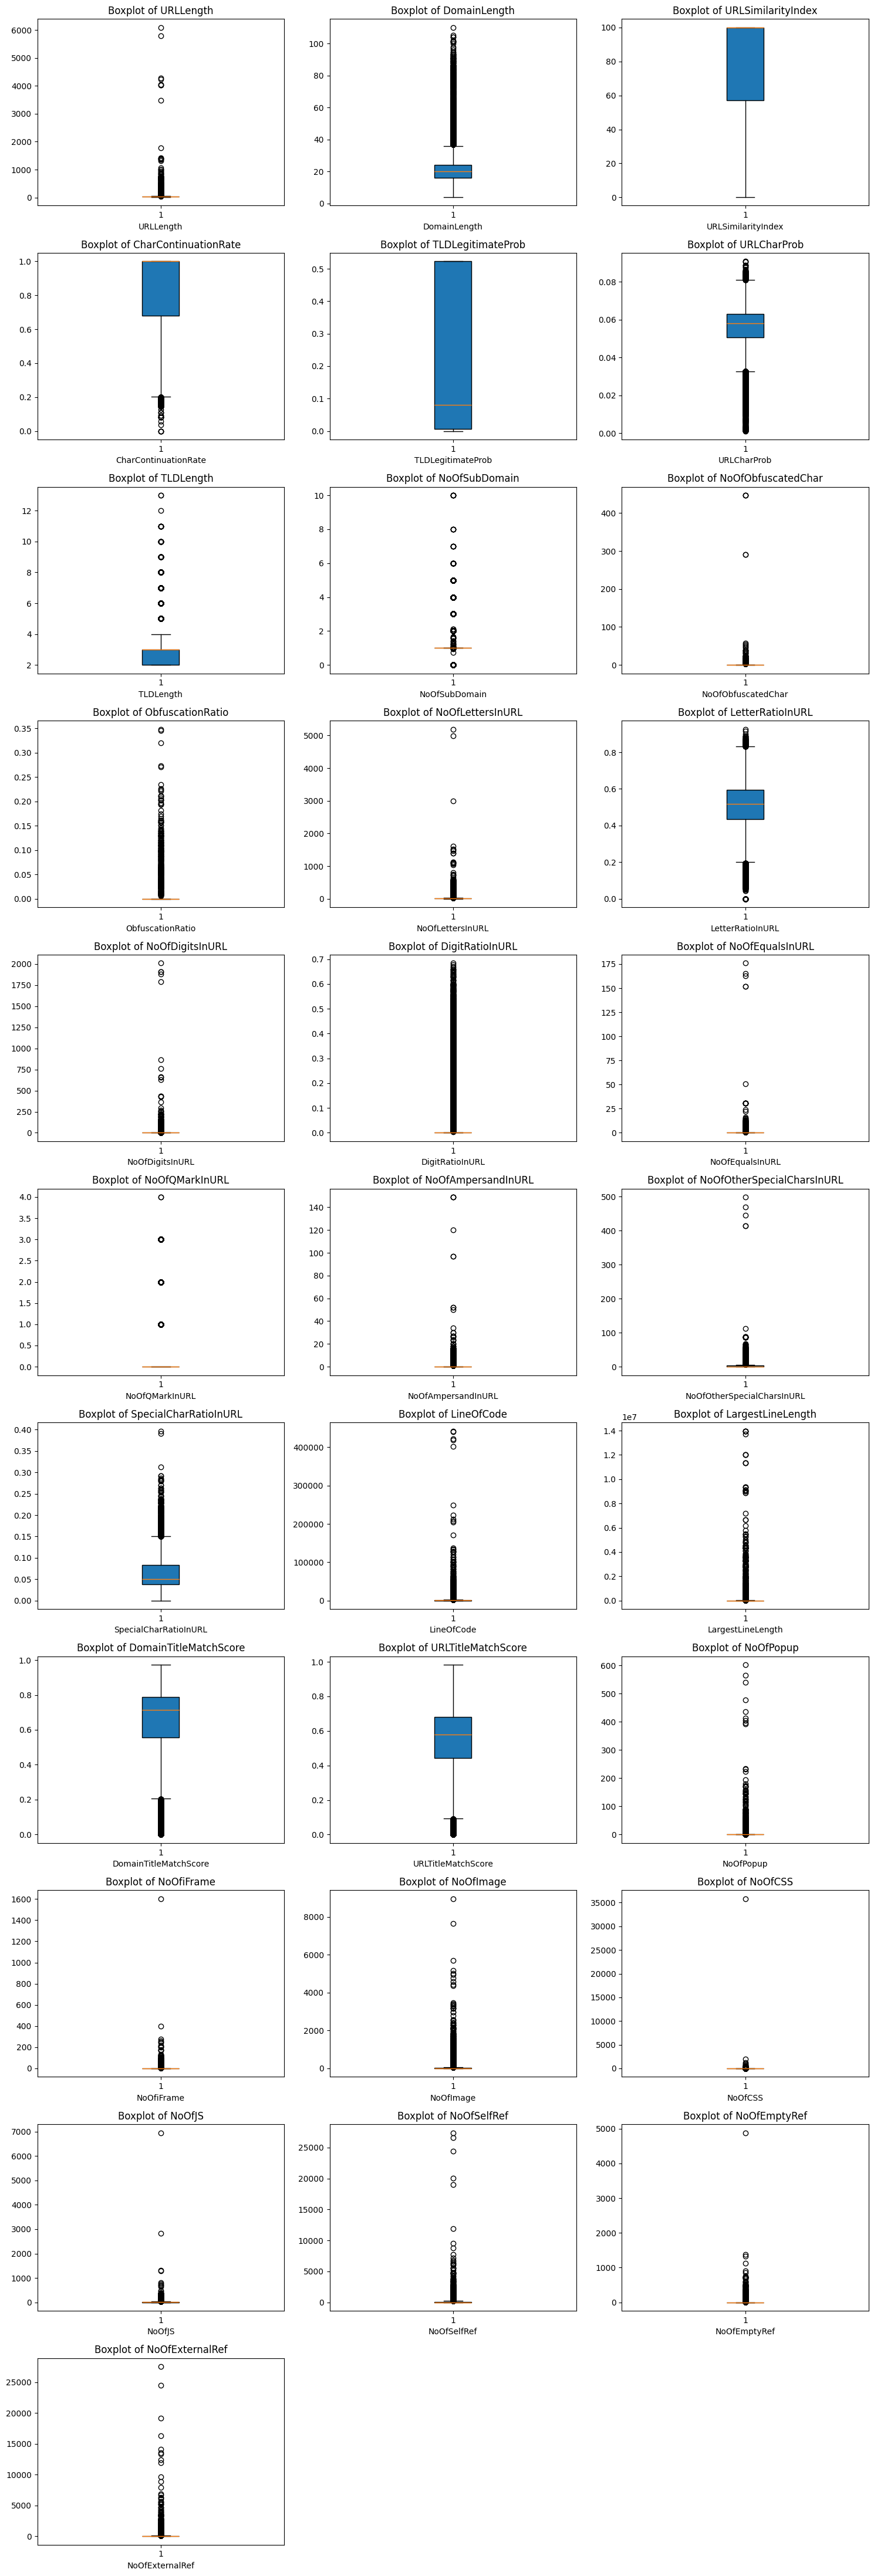

In [20]:
plot_boxplot(url, dist_feats)

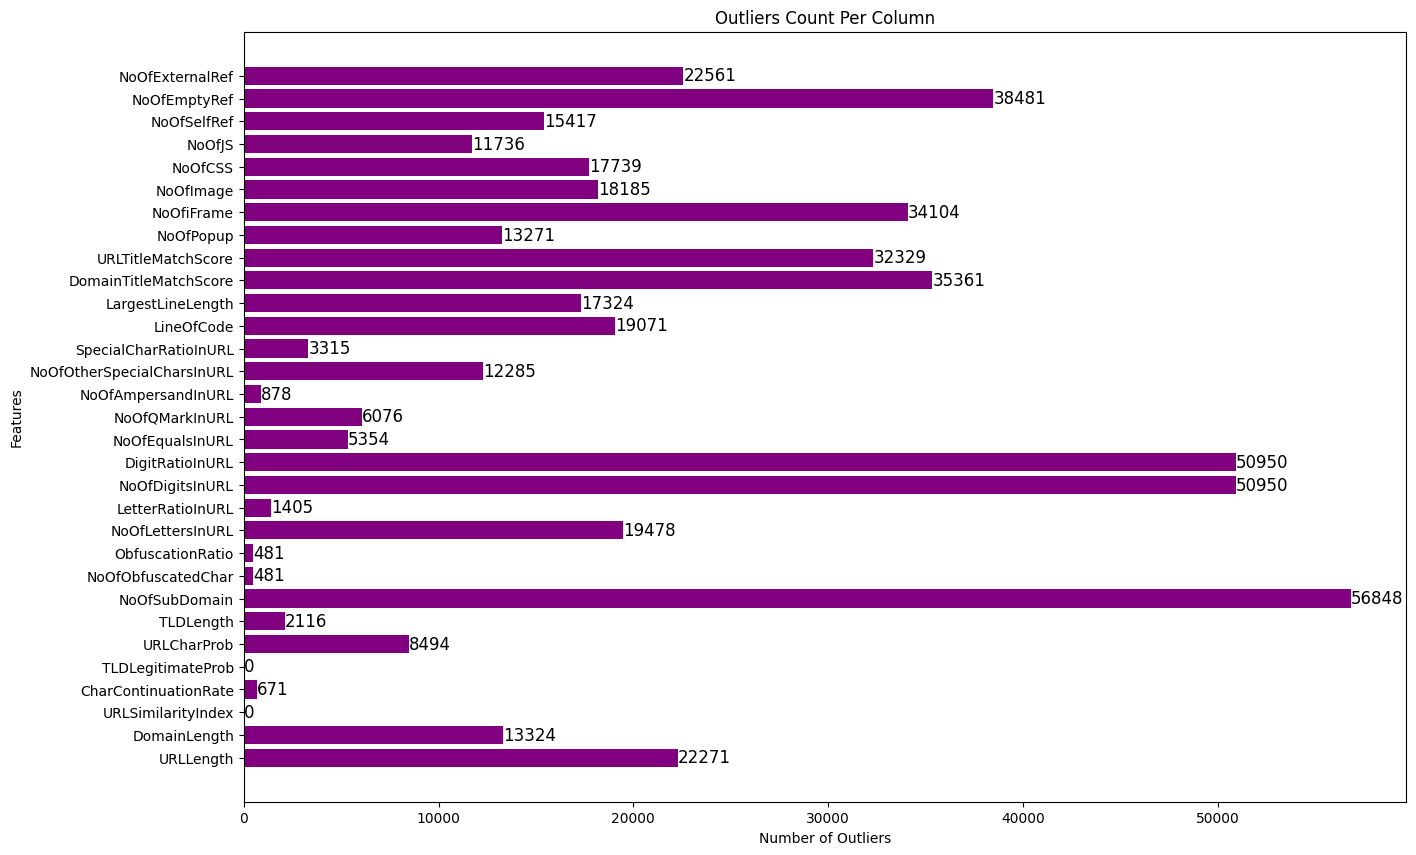

In [21]:
outlier_counts = {}

for col in dist_feats:  # Assuming dist_feats contains your column names
    Q1 = url[col].quantile(0.25)
    Q3 = url[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_counts[col] = ((url[col] < lower_bound) | (url[col] > upper_bound)).sum()

# Convert to list for ordering
cols = list(outlier_counts.keys())
counts = list(outlier_counts.values())

# Plot the outlier counts
plt.figure(figsize=(15, 10))
bars = plt.barh(y=cols, width=counts, color='purple')  

plt.xlabel('Number of Outliers')
plt.ylabel('Features')
plt.title('Outliers Count Per Column')

# Annotate each bar with the count value
for bar, count in zip(bars, counts):
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(count), va='center', fontsize=12)

plt.show()

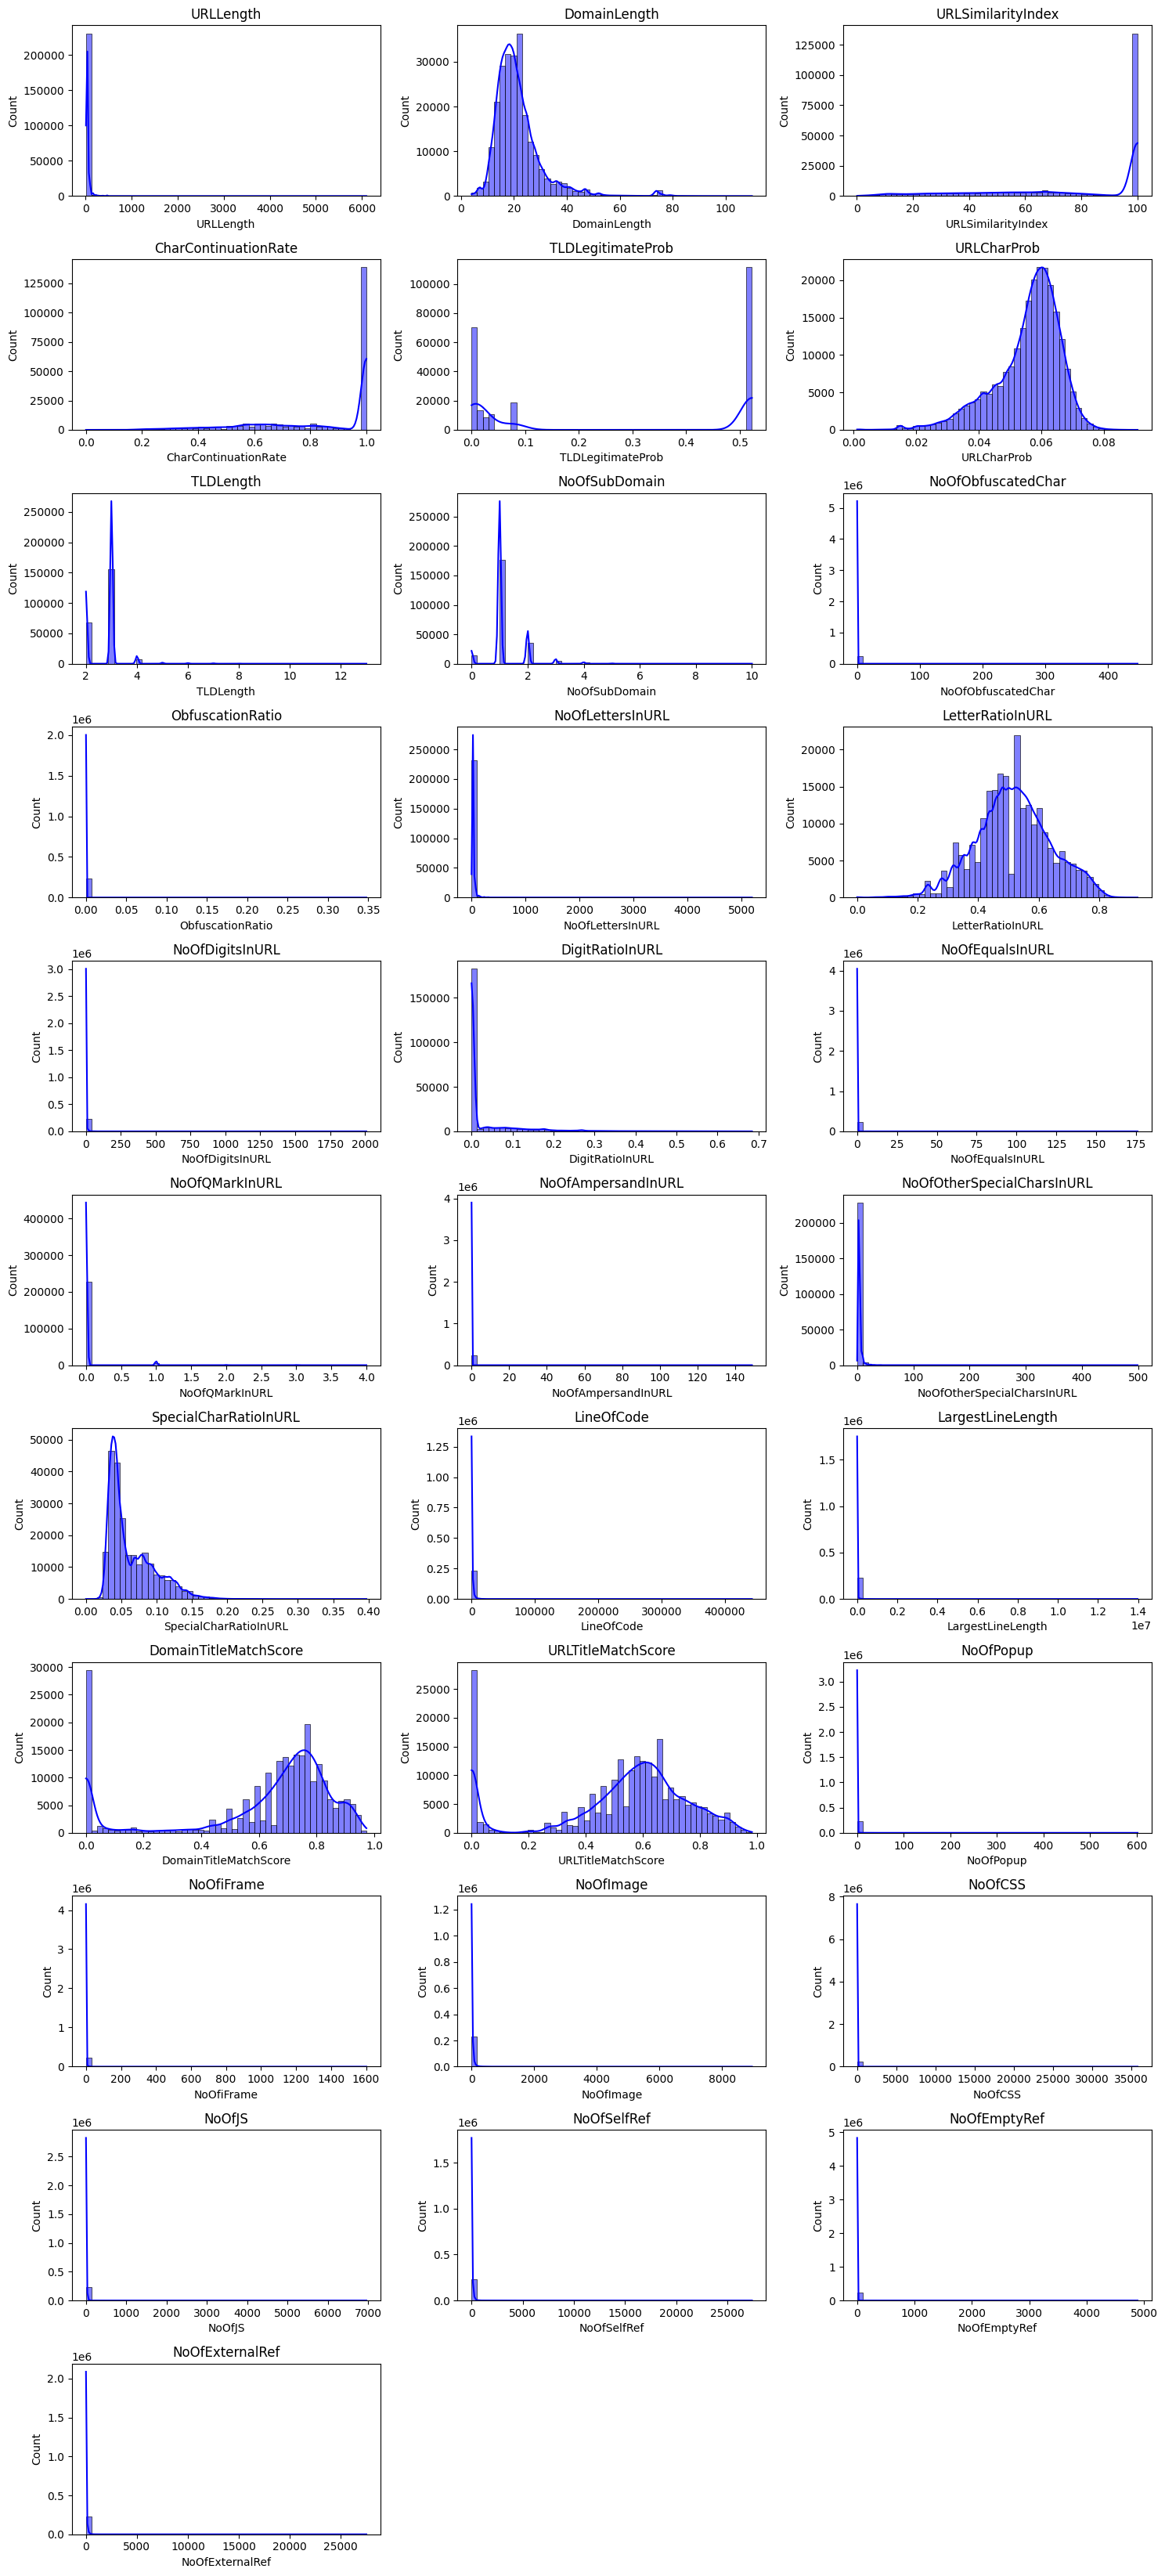

In [69]:
plot_distributions(url, dist_feats)

In [23]:
iqr_dict = {
    col: {'Q1': np.percentile(url[col], 25), 'Q3': np.percentile(url[col], 75)}
    for col in dist_feats
}

In [24]:
def remove_outliers(df, dist_feats, threshold):
    mask = pd.Series(True, index=df.index)  # Start with all rows as True

    for col in dist_feats:
        if col not in iqr_dict:
            raise ValueError(f"Column {col} not found in IQR dictionary")

        Q1 = iqr_dict[col]['Q1']
        Q3 = iqr_dict[col]['Q3']
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        mask &= (df[col] >= lower_bound) & (df[col] <= upper_bound)  # Combine conditions

    return df[mask]  # Remove outliers in one step


In [25]:
url_copy = url.copy()
url_copy = remove_outliers(url_copy, dist_feats, 1.5)
print(f"{(1 - url_copy.shape[0] / url.shape[0]) * 100:.2f}")

url_copy = url.copy()
url_copy = remove_outliers(url_copy, dist_feats, 2)
print(f"{(1 - url_copy.shape[0] / url.shape[0]) * 100:.2f}")

url_copy = url.copy()
url_copy = remove_outliers(url_copy, dist_feats, 3)
print(f"{(1 - url_copy.shape[0] / url.shape[0]) * 100:.2f}")

75.68
70.69
59.87


In [26]:
def cap_outliers(df, dist_feats, threshold):
    capped_df = df.copy()
    
    for col in dist_feats:
        # Compute Q1, Q3, and IQR
        Q1 = capped_df[col].quantile(0.25)
        Q3 = capped_df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Compute lower and upper bounds
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR
        
        # Cap outliers
        capped_df[col] = capped_df[col].clip(lower=lower_bound, upper=upper_bound)
    
    return capped_df

In [77]:
url_copy = url.copy()
url_copy = cap_outliers(url_copy, dist_feats, 1.5)

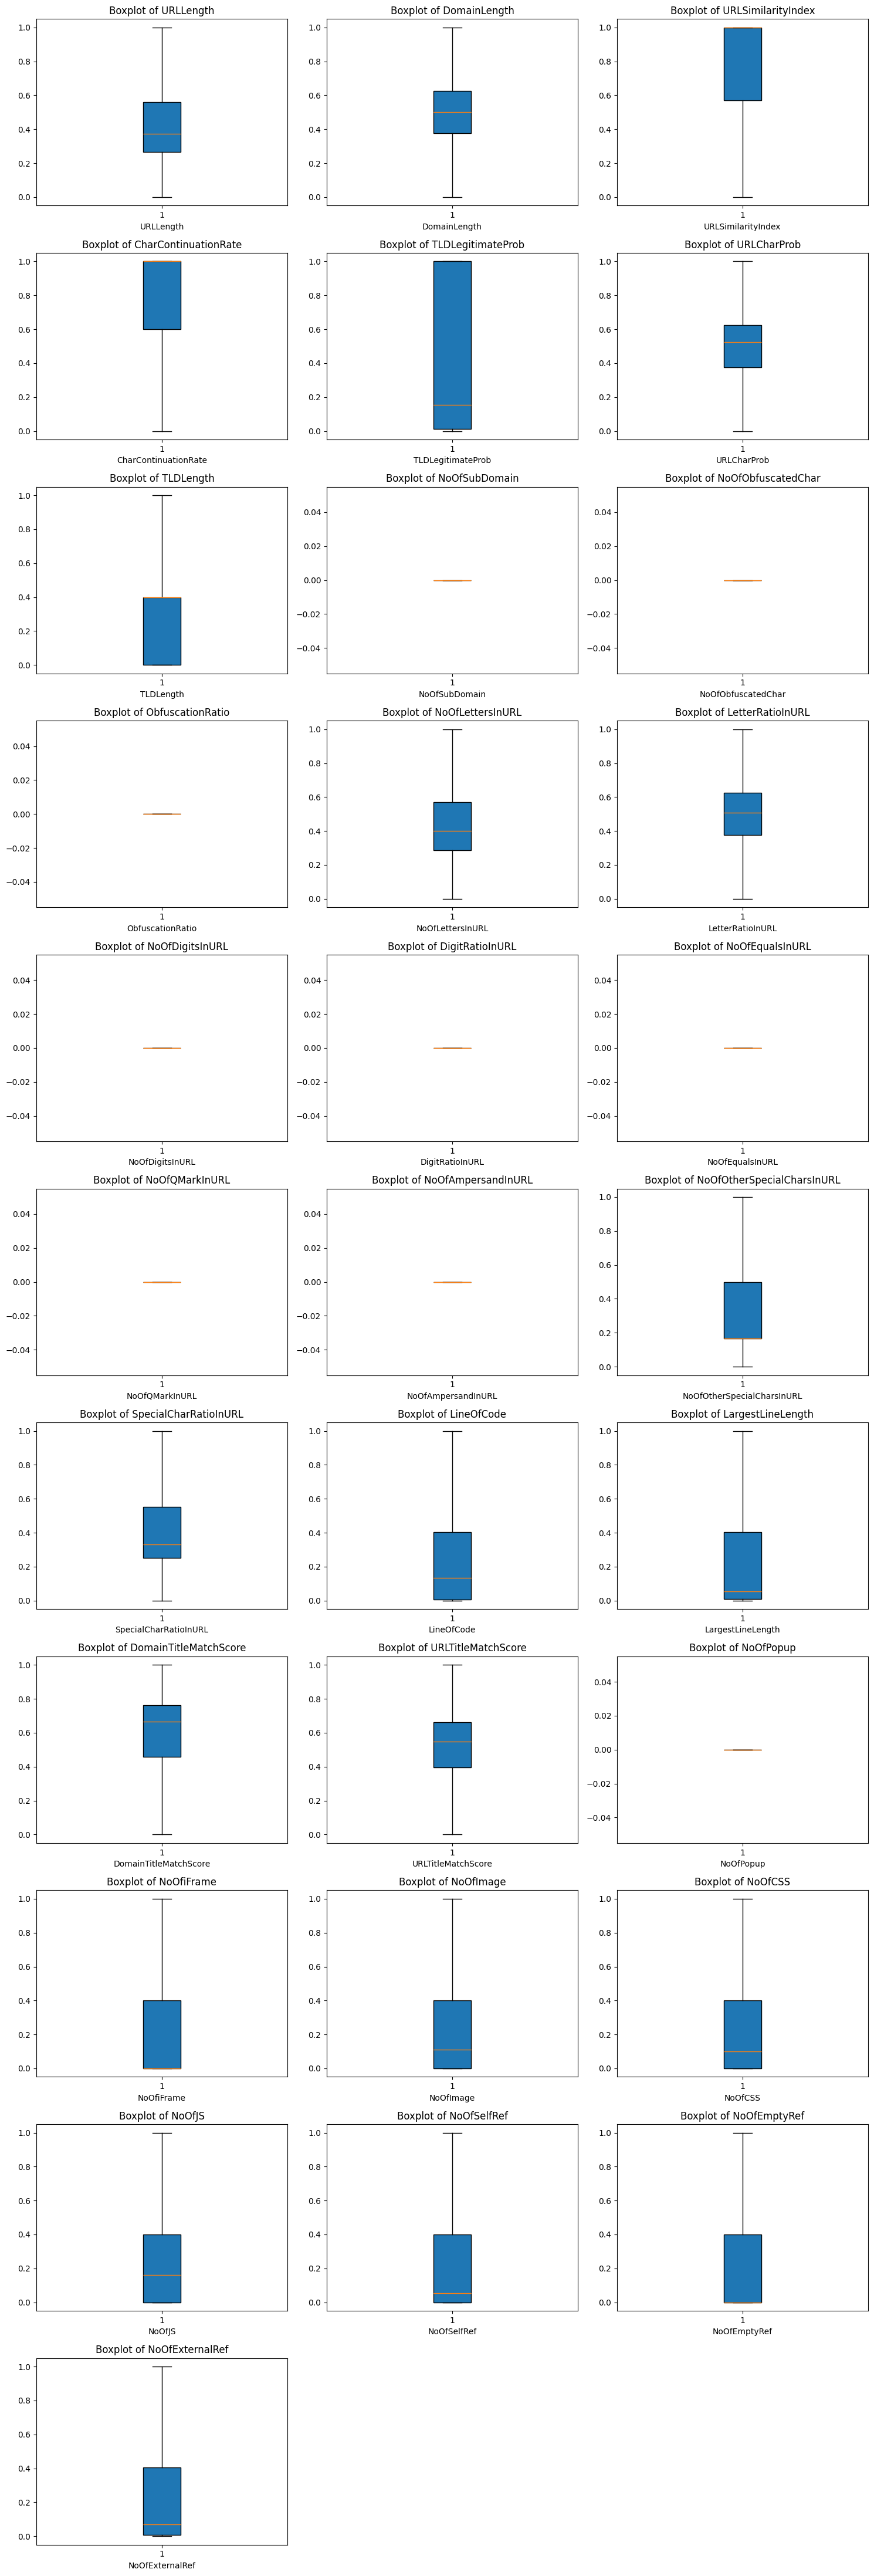

In [78]:
plot_boxplot(url_copy, dist_feats)

In [79]:
scaler = StandardScaler()
url_scaled = url_copy.copy()

if dist_feats:
    url_scaled[dist_feats] = scaler.fit_transform(url_copy[dist_feats])

In [80]:
scaler = MinMaxScaler()
if dist_feats:
    url_scaled[dist_feats] = scaler.fit_transform(url_scaled[dist_feats])

In [81]:
url_scaled = cap_outliers(url_scaled, dist_feats, 1.5)

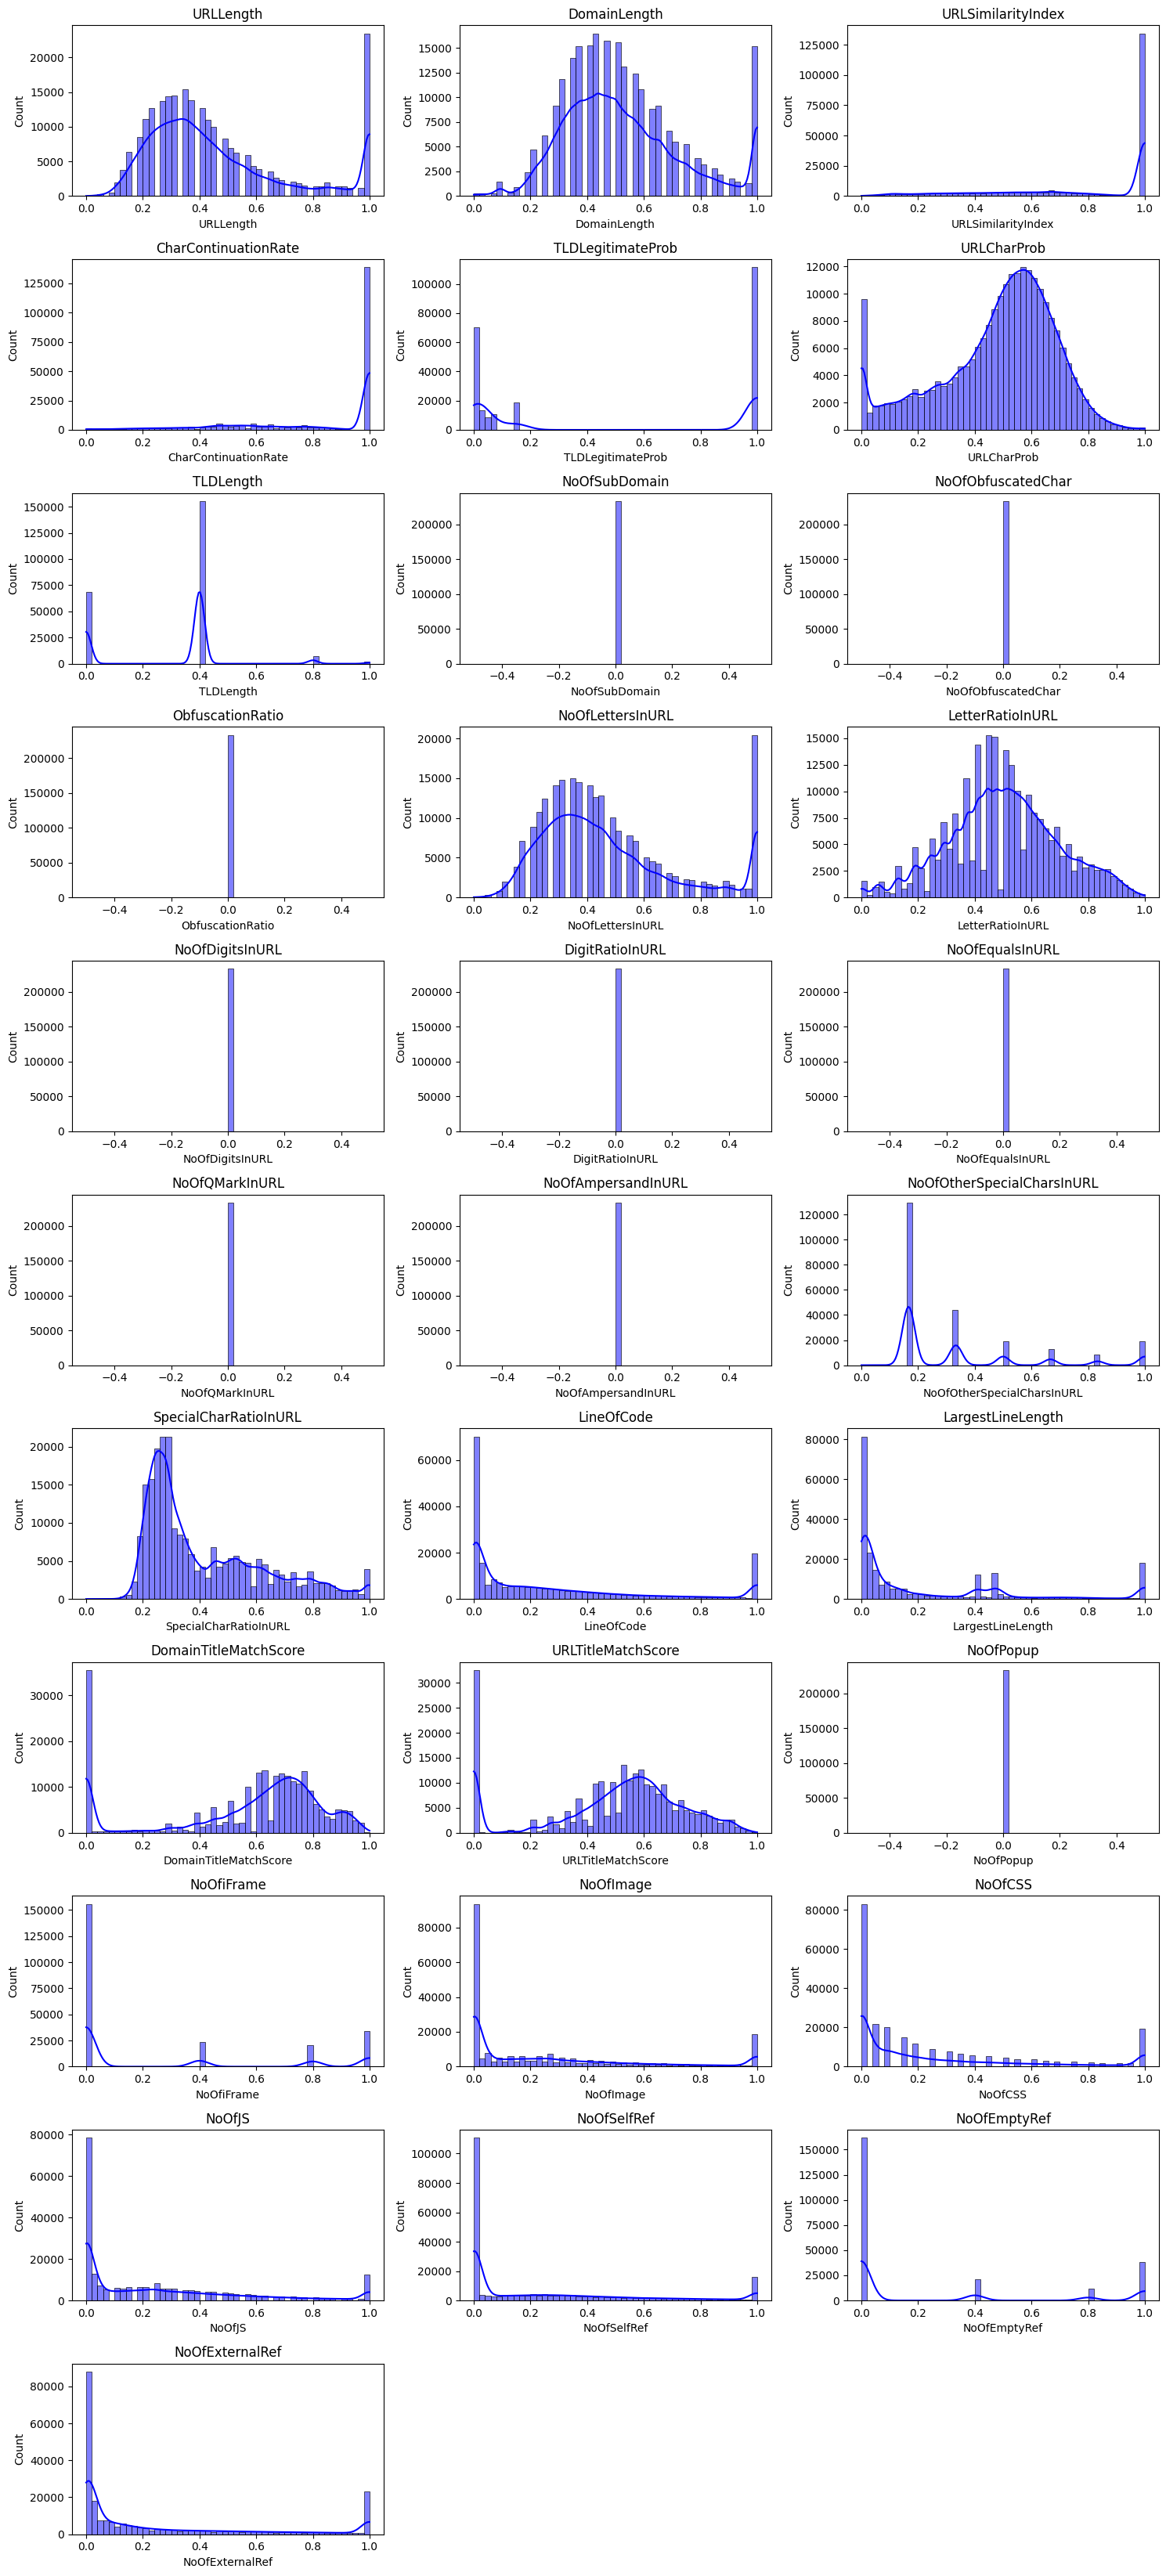

In [82]:
plot_distributions(url_scaled, dist_feats)

In [1]:
for col in url.select_dtypes(include=['object']).columns:
    print(f"{col} : {url[col].nunique()}")

NameError: name 'url' is not defined

In [ ]:
url = url.drop(
    columns = ['URL', 'Domain', 'Title']
)
url.shape

KeyError: "None of [Index(['Title'], dtype='object')] are in the [columns]"

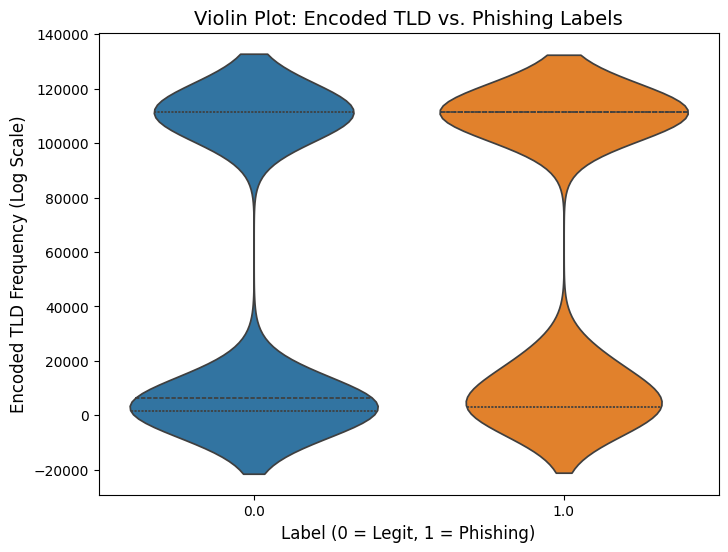

In [ ]:
frequency_dict = url['TLD'].value_counts().to_dict()
url['tld_encoded'] = url['TLD'].map(frequency_dict)

fig, ax = plt.subplots(figsize=(8, 6))

sns.violinplot(x=url["label"],y=url["tld_encoded"], 
    palette=["#1f77b4", "#ff7f0e"],inner="quartile", 
    bw=0.2,ax=ax
)

ax.set_title("Violin Plot: Encoded TLD vs. Phishing Labels", fontsize=14)
ax.set_xlabel("Label (0 = Legit, 1 = Phishing)", fontsize=12)
ax.set_ylabel("Encoded TLD Frequency (Log Scale)", fontsize=12)  
plt.show()

"""
Frequency encoding is used for the TLD column because one-hot encoding would add 695 columns, increasing complexity, 
while label encoding would assign arbitrary numbers from 0 to 694, which do not provide meaningful information. 

Additionally, frequency encoding is well-suited for tree-based models, as they can effectively split on numerical values 
and leverage frequency information for better pattern recognition.
"""

In [ ]:
url[dist_feats] = url_scaled[dist_feats]

In [ ]:
url.shape

(233391, 53)